## Desempeño
# Equipo 2
# Algoritmo A* (A-Star Search)

In [1]:
# Importar las librerías
import networkx as nx
import matplotlib.pyplot as plt
# Esta nueva libreria nos ayuda a seleccionar el nodo con mejor valor f(n)
import heapq

In [2]:
# Creamos el grafo

grafo = nx.DiGraph()

grafo.add_weighted_edges_from([
    ("Centro", "Norte", 4),
    ("Centro", "Sur", 3),

    ("Norte", "Este", 5),
    ("Norte", "Hospital", 7),

    ("Sur", "Hospital", 4),
    ("Sur", "Universidad", 6),

    ("Este", "Aeropuerto", 8),

    ("Hospital", "Aeropuerto", 5),
    ("Hospital", "Universidad", 2),

    ("Universidad", "Aeropuerto", 4)
])

In [3]:
# Valores heurísticos
# Estimación del costo que falta para llegar al Aeropuerto

heuristica = {
    "Centro": 10,
    "Norte": 9,
    "Sur": 8,
    "Este": 7,
    "Hospital": 4,
    "Universidad": 3,
    "Aeropuerto": 0
}

In [4]:
# Posiciones de los nodos

pos = {
    "Centro": (0, 2),
    "Norte": (2, 4),
    "Sur": (2, 0),
    "Este": (4, 4),
    "Hospital": (4, 2),
    "Universidad": (4, 0),
    "Aeropuerto": (7, 2)
}

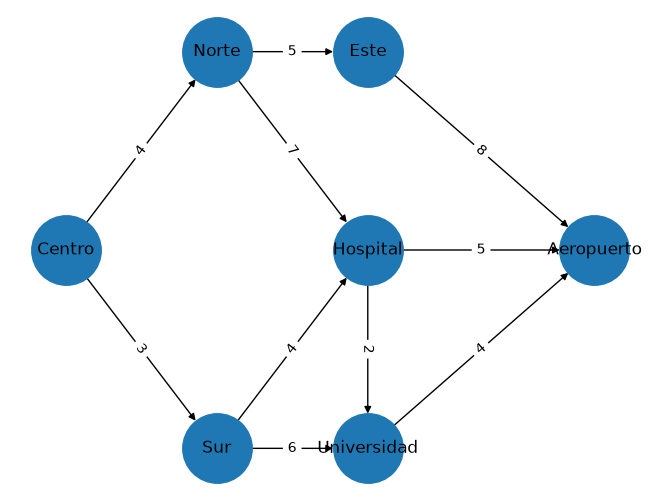

In [5]:
# Imprimimos el grafo

nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=2500,
    arrows=True
)

labels = nx.get_edge_attributes(grafo, "weight")

nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)

plt.show()

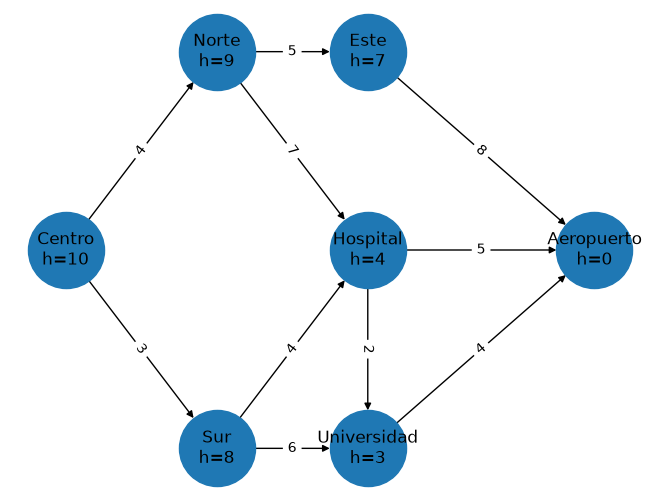

In [6]:
# Mostrar el grafo con los valores heurísticos

etiquetas_nodos = {
    nodo: f"{nodo}\nh={heuristica[nodo]}"
    for nodo in grafo.nodes()
}

nx.draw(
    grafo,
    pos,
    labels=etiquetas_nodos,
    with_labels=True,
    node_size=3000,
    arrows=True
)

labels = nx.get_edge_attributes(grafo, "weight")

nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)

plt.show()

In [7]:
# Función para visualizar el proceso de búsqueda A*

def visualizar_busqueda(
    grafo,
    pos,
    actual,
    explorados,
    frontera,
    ruta_parcial=None
):

    plt.figure(figsize=(10, 6))

    # Obtenemos los nodos que están en la frontera
    nodos_frontera = [
        nodo for f, nodo in frontera
    ]

    # Colores de los nodos
    colores = []

    for nodo in grafo.nodes():

        # Nodo que se está analizando actualmente
        if nodo == actual:
            colores.append("orange")

        # Nodos ya explorados
        elif nodo in explorados:
            colores.append("lightgreen")

        # Nodos pendientes en la frontera
        elif nodo in nodos_frontera:
            colores.append("yellow")

        # Nodos que todavía no se han procesado
        else:
            colores.append("lightblue")

    # Dibujamos el grafo
    nx.draw(
        grafo,
        pos,
        with_labels=True,
        node_color=colores,
        node_size=3000,
        arrows=True
    )

    # Obtenemos los pesos de las aristas
    labels = nx.get_edge_attributes(
        grafo,
        "weight"
    )

    # Dibujamos los pesos
    nx.draw_networkx_edge_labels(
        grafo,
        pos,
        edge_labels=labels
    )

    # Dibujamos la trayectoria parcial
    if ruta_parcial and len(ruta_parcial) > 1:

        aristas_parciales = list(
            zip(
                ruta_parcial,
                ruta_parcial[1:]
            )
        )

        nx.draw_networkx_edges(
            grafo,
            pos,
            edgelist=aristas_parciales,
            width=4,
            arrows=True
        )

    plt.title(
        f"Búsqueda A* - Nodo actual: {actual}"
    )

    plt.show()

In [8]:
# Algoritmo A*

def a_estrella(grafo, inicio, meta, heuristica, pos):

    # Frontera de búsqueda
    frontera = []

    # Guardamos: f(n), nodo
    heapq.heappush(
        frontera,
        (heuristica[inicio], inicio)
    )

    # Nodos explorados
    explorados = []

    # Nodo anterior
    anterior = {
        inicio: None
    }

    # Costo acumulado g(n)
    costo = {
        inicio: 0
    }

    while frontera:

        # Seleccionamos el nodo con menor f(n)
        f_actual, actual = heapq.heappop(frontera)

        # Agregamos el nodo actual a explorados
        explorados.append(actual)

        print("\nNodo actual:", actual)
        print("g(n):", costo[actual])
        print("h(n):", heuristica[actual])
        print(
            "f(n):",
            costo[actual] + heuristica[actual]
        )

        # Mostramos los nodos explorados
        print("Explorados:", explorados)

        # Revisamos vecinos solamente
        # si todavía no llegamos a la meta
        if actual != meta:

            for vecino in grafo.successors(actual):

                peso = grafo[actual][vecino]["weight"]

                nuevo_costo = (
                    costo[actual] + peso
                )

                # Si encontramos una mejor ruta
                if (
                    vecino not in costo
                    or nuevo_costo < costo[vecino]
                ):

                    costo[vecino] = nuevo_costo

                    # f(n) = g(n) + h(n)
                    f = (
                        nuevo_costo
                        + heuristica[vecino]
                    )

                    heapq.heappush(
                        frontera,
                        (f, vecino)
                    )

                    anterior[vecino] = actual

                    print(
                        "  Vecino:", vecino,
                        "| g =", nuevo_costo,
                        "| h =", heuristica[vecino],
                        "| f =", f
                    )

        # Mostramos la frontera
        print(
            "Frontera:",
            [
                (nodo, f)
                for f, nodo
                in sorted(frontera)
            ]
        )

        # Construimos la trayectoria parcial
        ruta_parcial = []

        nodo_ruta = actual

        while nodo_ruta is not None:

            ruta_parcial.append(nodo_ruta)

            nodo_ruta = anterior[nodo_ruta]

        ruta_parcial.reverse()

        # Visualización de este paso
        visualizar_busqueda(
            grafo,
            pos,
            actual,
            explorados,
            frontera,
            ruta_parcial
        )

        # Si llegamos a la meta
        if actual == meta:
            break

    # Reconstruimos la ruta final
    ruta = []

    actual = meta

    while actual is not None:

        ruta.append(actual)

        actual = anterior[actual]

    ruta.reverse()

    return ruta, costo[meta]


Nodo actual: Centro
g(n): 0
h(n): 10
f(n): 10
Explorados: ['Centro']
  Vecino: Norte | g = 4 | h = 9 | f = 13
  Vecino: Sur | g = 3 | h = 8 | f = 11
Frontera: [('Sur', 11), ('Norte', 13)]


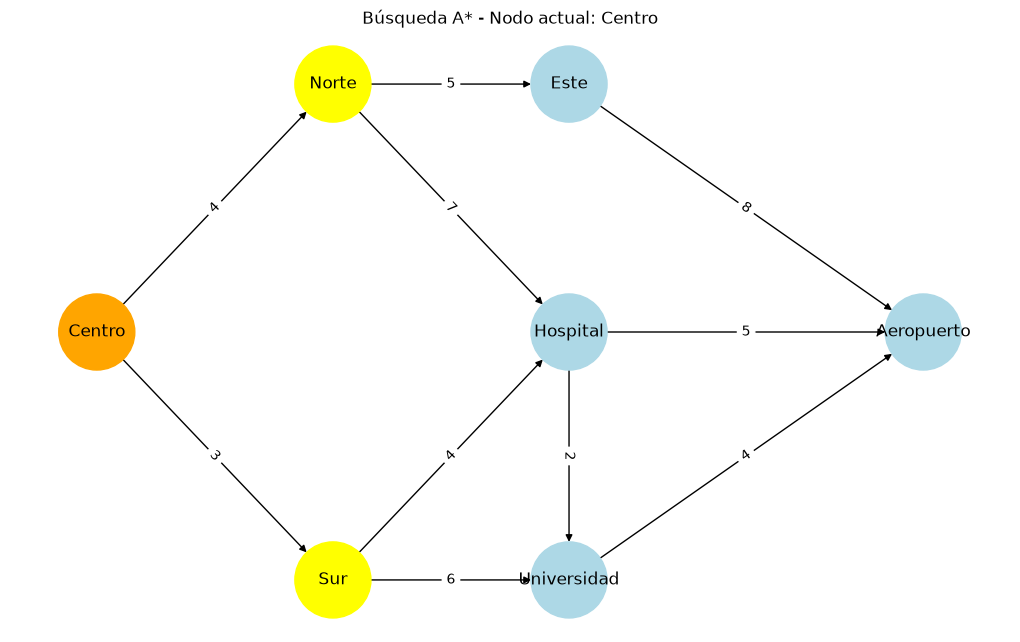


Nodo actual: Sur
g(n): 3
h(n): 8
f(n): 11
Explorados: ['Centro', 'Sur']
  Vecino: Hospital | g = 7 | h = 4 | f = 11
  Vecino: Universidad | g = 9 | h = 3 | f = 12
Frontera: [('Hospital', 11), ('Universidad', 12), ('Norte', 13)]


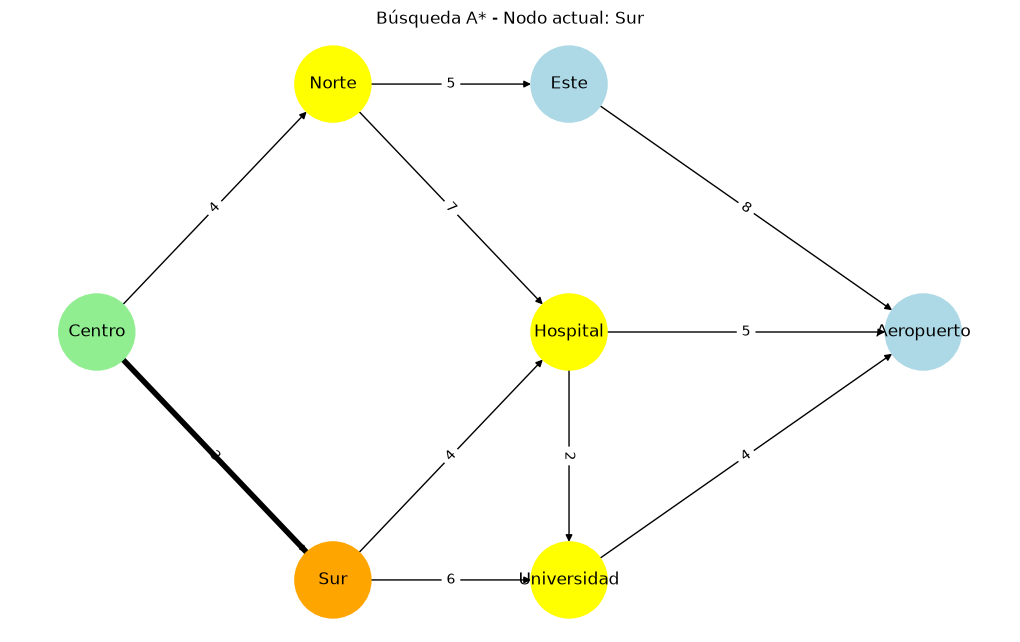


Nodo actual: Hospital
g(n): 7
h(n): 4
f(n): 11
Explorados: ['Centro', 'Sur', 'Hospital']
  Vecino: Aeropuerto | g = 12 | h = 0 | f = 12
Frontera: [('Aeropuerto', 12), ('Universidad', 12), ('Norte', 13)]


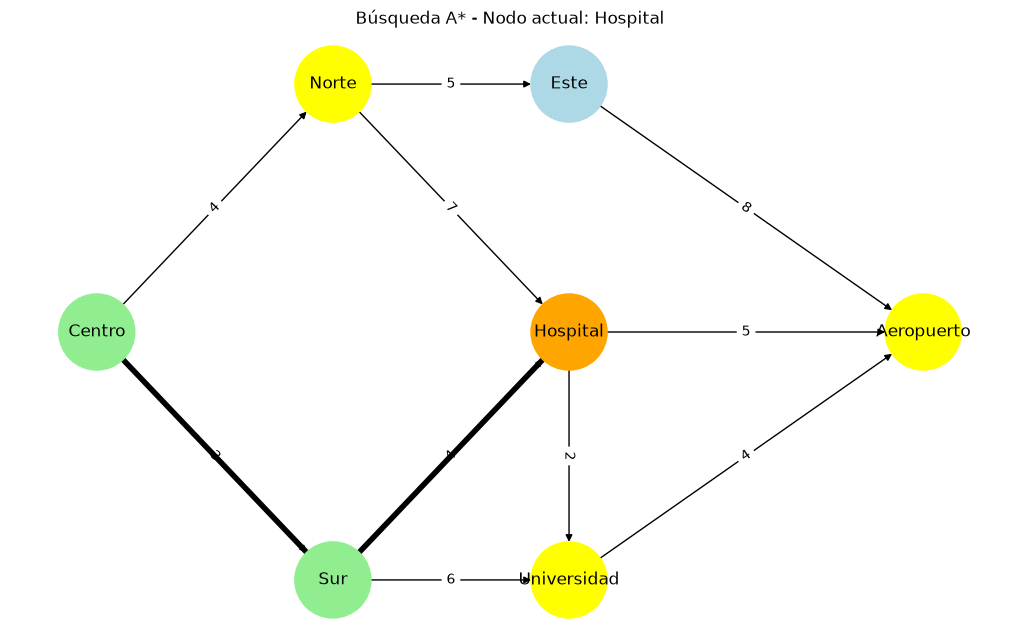


Nodo actual: Aeropuerto
g(n): 12
h(n): 0
f(n): 12
Explorados: ['Centro', 'Sur', 'Hospital', 'Aeropuerto']
Frontera: [('Universidad', 12), ('Norte', 13)]


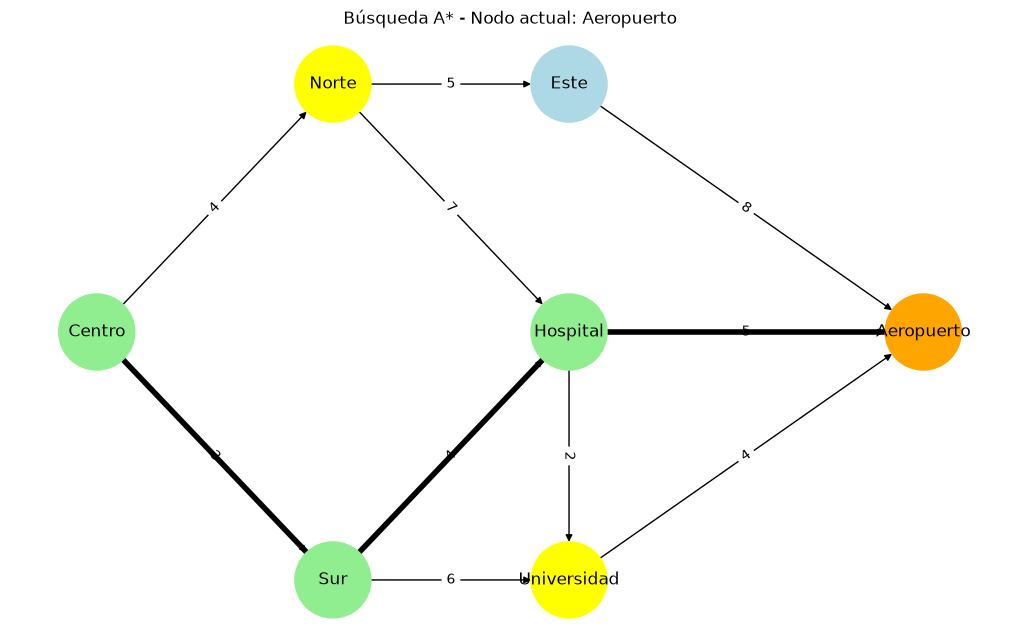

In [9]:
# Ejecutamos A*

ruta, costo_total = a_estrella(
    grafo,
    inicio="Centro",
    meta="Aeropuerto",
    heuristica=heuristica,
    pos=pos
)

In [10]:
# Imprimir resultado

print("\nRuta encontrada por A*:")
print(ruta)

print("\nCosto total:")
print(costo_total)


Ruta encontrada por A*:
['Centro', 'Sur', 'Hospital', 'Aeropuerto']

Costo total:
12


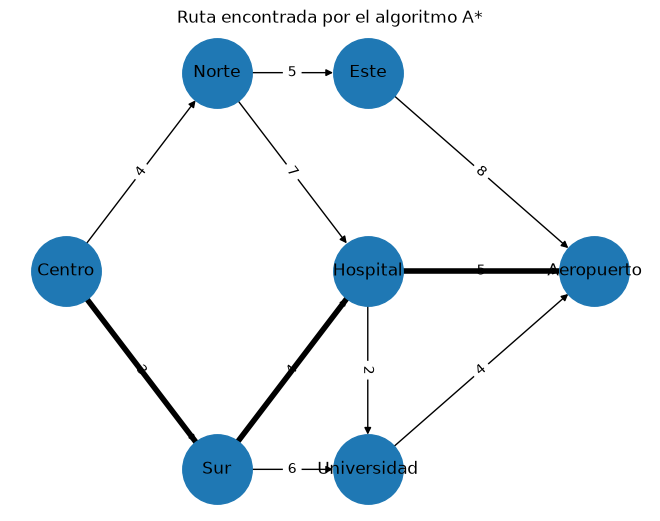

In [11]:
# Dibujamos nuevamente el grafo

nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=2500,
    arrows=True
)

labels = nx.get_edge_attributes(grafo, "weight")

nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)

# Convertimos la ruta en aristas

aristas_ruta = list(
    zip(ruta, ruta[1:])
)

# Dibujamos la ruta encontrada más gruesa

nx.draw_networkx_edges(
    grafo,
    pos,
    edgelist=aristas_ruta,
    width=4,
    arrows=True
)

plt.title("Ruta encontrada por el algoritmo A*")

plt.show()